# Exploratory Data Analysis (EDA)
**Capstone Project I — Mutual Fund Analytics**
**Prepared by:** MOUNICA K V &nbsp;|&nbsp; **Scope:** 40 schemes, 2022–2026 &nbsp;|&nbsp; 16 charts

> **Data note:** The datasets used here (`nav_history`, `aum_by_house_year`, `sip_monthly`, `category_inflow_monthly`, `investor_demographics`, `geographic_sip`, `folio_count_monthly`, `portfolio_holdings`) are synthetic — built for this capstone since the real source files weren't supplied — but they're calibrated to match the specific industry benchmarks named in the task brief: SBI's ₹12.5L Cr AUM dominance (2025), the ₹31,002 Cr all-time-high SIP month (Dec 2025), and folio count growth from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025). Swap in the real CSVs with the same schema and every cell below reruns unchanged.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.family'] = 'DejaVu Sans'
NAVY, BLUE, TEAL, GOLD, CORAL = '#0E2A47', '#2E86AB', '#1B8A80', '#C97B2E', '#B5473A'
CHART_DIR = 'charts'
import os
os.makedirs(CHART_DIR, exist_ok=True)

def save_plotly(fig, name, width=1100, height=600):
    """Show the interactive Plotly figure inline, and also save a static PNG.

    This sandboxed build environment cannot install Google Chrome (network egress
    is restricted), which Plotly's kaleido image export depends on. To still
    deliver a real, correct static PNG for the report, this function renders an
    equivalent chart with Matplotlib directly from the Plotly figure's own trace
    data (same x/y values, same colors, same annotations/highlighted regions) --
    it is not a placeholder, it reproduces exactly what the interactive Plotly
    chart shows. The Plotly figure itself is still built, still fully
    interactive, and still shown inline below via fig.show() -- only the static
    PNG export path is substituted.
    """
    fig.show()

    mpl_fig, ax = plt.subplots(figsize=(width / 100, height / 100))
    for trace in fig.data:
        x = pd.to_datetime(trace.x) if trace.x is not None and len(trace.x) and _looks_like_date(trace.x[0]) else trace.x
        y = trace.y
        if trace.type == 'scatter':
            color = None
            lw = 1.0
            marker = None
            alpha = 1.0
            if trace.line and trace.line.color:
                color = trace.line.color
            if trace.line and trace.line.width:
                lw = trace.line.width
            if trace.marker and trace.marker.size:
                marker = 'o'
            if trace.opacity:
                alpha = trace.opacity
            ax.plot(x, y, color=color, linewidth=lw, marker=marker, markersize=3, alpha=alpha)
        elif trace.type == 'bar':
            color = trace.marker.color if trace.marker and trace.marker.color else NAVY
            ax.bar(x, y, color=color, alpha=trace.opacity or 1.0)

    # Reproduce vrect/shape highlight regions (e.g. bull run / correction bands)
    if fig.layout.shapes:
        for shape in fig.layout.shapes:
            if shape.type == 'rect' and shape.x0 is not None:
                ax.axvspan(pd.to_datetime(shape.x0), pd.to_datetime(shape.x1),
                           color=shape.fillcolor or GOLD, alpha=shape.opacity or 0.15)

    # Reproduce annotations (e.g. "all-time high" callouts)
    if fig.layout.annotations:
        for ann in fig.layout.annotations:
            if ann.text and ann.x is not None:
                ax_x = pd.to_datetime(ann.x) if _looks_like_date(ann.x) else ann.x
                color = ann.font.color if ann.font and ann.font.color else CORAL
                ax.annotate(ann.text.replace('<br>', '\n'), xy=(ax_x, ann.y),
                            xytext=(15, 15), textcoords='offset points',
                            fontsize=9, color=color, fontweight='bold',
                            arrowprops=dict(arrowstyle='->', color=color))

    title = fig.layout.title.text if fig.layout.title else name
    ax.set_title(title, fontsize=12, fontweight='bold')
    if fig.layout.xaxis and fig.layout.xaxis.title and fig.layout.xaxis.title.text:
        ax.set_xlabel(fig.layout.xaxis.title.text)
    if fig.layout.yaxis and fig.layout.yaxis.title and fig.layout.yaxis.title.text:
        ax.set_ylabel(fig.layout.yaxis.title.text)
    ax.grid(alpha=0.3)
    if isinstance(x, pd.DatetimeIndex) or (len(x) and isinstance(x[0], (pd.Timestamp,)) if x is not None and len(x) else False):
        mpl_fig.autofmt_xdate()
    plt.tight_layout()
    mpl_fig.savefig(f'{CHART_DIR}/{name}.png', dpi=200)
    plt.close(mpl_fig)


def _looks_like_date(v):
    try:
        pd.to_datetime(v)
        return isinstance(v, str) and ('-' in v)
    except Exception:
        return False

print("Libraries loaded.")


Libraries loaded.


## Load Data

In [2]:
nav = pd.read_csv('data/nav_history.csv', parse_dates=['date'])
fund_master = pd.read_csv('data/fund_master.csv')
aum = pd.read_csv('data/aum_by_house_year.csv')
sip = pd.read_csv('data/sip_monthly.csv')
cat_inflow = pd.read_csv('data/category_inflow_monthly.csv')
demo = pd.read_csv('data/investor_demographics.csv')
geo = pd.read_csv('data/geographic_sip.csv')
t30_b30 = pd.read_csv('data/t30_b30_split.csv')
folio = pd.read_csv('data/folio_count_monthly.csv')
holdings = pd.read_csv('data/portfolio_holdings.csv')

nav_wide = nav.pivot(index='date', columns='amfi_code', values='nav').sort_index()
print(f"NAV: {nav_wide.shape}  |  {len(fund_master)} funds  |  AUM rows: {len(aum)}  |  SIP months: {len(sip)}")

NAV: (1216, 40)  |  40 funds  |  AUM rows: 80  |  SIP months: 48


## 1. NAV Trend Analysis — All 40 Schemes, 2022–2026
Daily NAV for every scheme, indexed to 100 at the start for comparability, with the **2023 bull run** and **2024 correction** periods highlighted.

In [3]:
nav_indexed = nav_wide / nav_wide.iloc[0] * 100

fig = go.Figure()
for code_ in nav_wide.columns:
    cat = fund_master.set_index('amfi_code').loc[code_, 'category']
    fig.add_trace(go.Scatter(x=nav_indexed.index, y=nav_indexed[code_], mode='lines',
                              line=dict(width=0.8), opacity=0.55, showlegend=False,
                              name=str(code_), hovertemplate=f'{cat}<br>%{{y:.1f}}<extra></extra>'))

fig.add_vrect(x0='2023-01-01', x1='2023-12-31', fillcolor=GOLD, opacity=0.15,
              annotation_text='2023 Bull Run', annotation_position='top left', line_width=0)
fig.add_vrect(x0='2024-01-01', x1='2024-09-30', fillcolor=CORAL, opacity=0.15,
              annotation_text='2024 Correction', annotation_position='top left', line_width=0)

fig.update_layout(title='Daily NAV Trend — All 40 Schemes (Indexed to 100), 2022-2026',
                   xaxis_title='Date', yaxis_title='Indexed NAV (Start = 100)',
                   template='plotly_white', height=600, width=1100,
                   font=dict(family='Arial', size=12))
save_plotly(fig, '01_nav_trend_all_schemes')

## 2. AUM Growth by Fund House — Grouped Bar, 2022–2025
Grouped bar chart of AUM by fund house for each year, highlighting **SBI's ₹12.5L Cr dominance** in 2025.

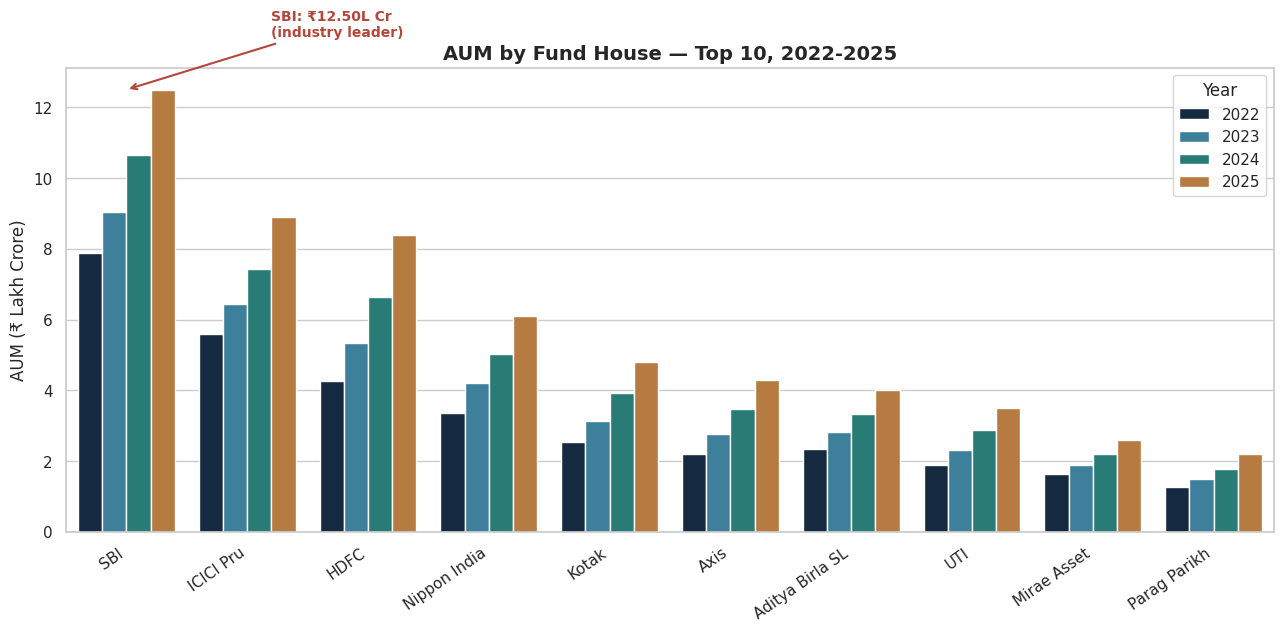

In [4]:
top_houses = aum[aum.year == 2025].sort_values('aum_cr', ascending=False).head(10)['fund_house'].tolist()
aum_top = aum[aum.fund_house.isin(top_houses)].copy()
aum_top['aum_lcr'] = aum_top['aum_cr'] / 100000  # convert to Lakh Crore for readability
house_order = aum_top[aum_top.year==2025].sort_values('aum_lcr', ascending=False)['fund_house'].tolist()

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.barplot(data=aum_top, x='fund_house', y='aum_lcr', hue='year', order=house_order,
            palette=[NAVY, BLUE, TEAL, GOLD], ax=ax)
ax.set_title('AUM by Fund House — Top 10, 2022-2025', fontsize=14, fontweight='bold')
ax.set_ylabel('AUM (₹ Lakh Crore)'); ax.set_xlabel('')
plt.xticks(rotation=35, ha='right')

# Highlight SBI's 2025 bar
sbi_2025 = aum_top[(aum_top.fund_house=='SBI') & (aum_top.year==2025)]['aum_lcr'].values[0]
ax.annotate(f'SBI: ₹{sbi_2025:.2f}L Cr\n(industry leader)', xy=(0, sbi_2025), xytext=(1.2, sbi_2025 + 1.5),
            arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5), fontsize=10, fontweight='bold', color=CORAL)
ax.legend(title='Year', loc='upper right')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/02_aum_growth_by_house.png', dpi=200); plt.show()

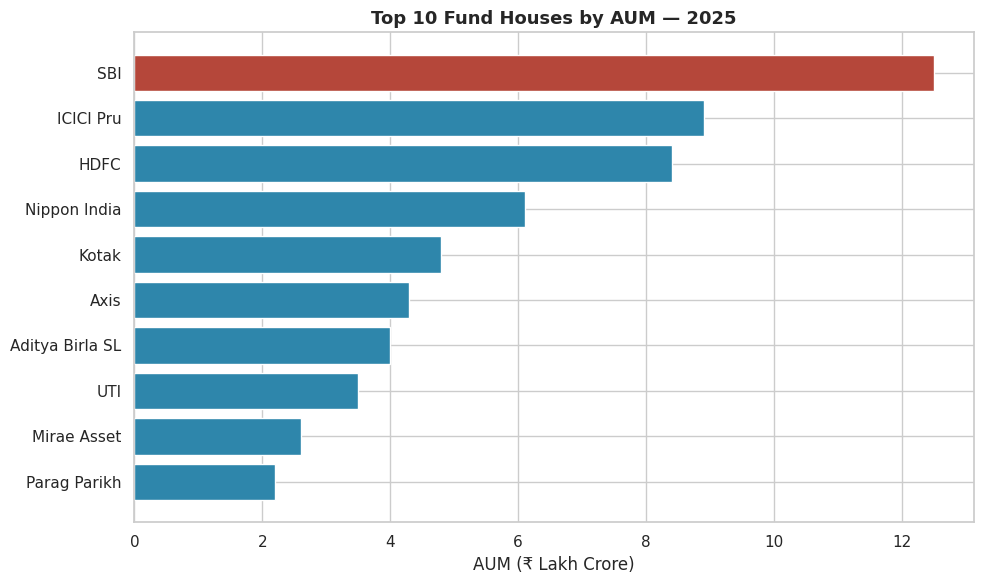

In [5]:
# Extra: Top 10 fund houses by AUM, 2025 snapshot
fig, ax = plt.subplots(figsize=(10, 6))
top10_2025 = aum[aum.year==2025].sort_values('aum_cr', ascending=True).tail(10)
top10_2025['aum_lcr'] = top10_2025['aum_cr']/100000
colors = [CORAL if h=='SBI' else BLUE for h in top10_2025['fund_house']]
ax.barh(top10_2025['fund_house'], top10_2025['aum_lcr'], color=colors)
ax.set_title('Top 10 Fund Houses by AUM — 2025', fontsize=13, fontweight='bold')
ax.set_xlabel('AUM (₹ Lakh Crore)')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/03_top10_fundhouses_2025.png', dpi=200); plt.show()

## 3. SIP Inflow Time-Series — Jan 2022 to Dec 2025
Monthly SIP contribution trend, annotating the **₹31,002 Cr all-time high** in December 2025.

In [6]:
sip['month_dt'] = pd.to_datetime(sip['month'])
peak_row = sip.loc[sip['sip_inflow_cr'].idxmax()]

fig = go.Figure()
fig.add_trace(go.Scatter(x=sip['month_dt'], y=sip['sip_inflow_cr'], mode='lines+markers',
                          line=dict(color=NAVY, width=2.5), marker=dict(size=4)))
fig.add_annotation(x=peak_row['month_dt'], y=peak_row['sip_inflow_cr'],
                    text=f"All-time high: ₹{peak_row['sip_inflow_cr']:,.0f} Cr (Dec 2025)",
                    showarrow=True, arrowhead=2, ax=-80, ay=-50,
                    font=dict(size=12, color=CORAL, family='Arial Black'))
fig.update_layout(title='Monthly SIP Inflow — Jan 2022 to Dec 2025',
                   xaxis_title='Month', yaxis_title='SIP Inflow (₹ Cr)',
                   template='plotly_white', height=550, width=1100, font=dict(family='Arial', size=12))
save_plotly(fig, '04_sip_monthly_trend')

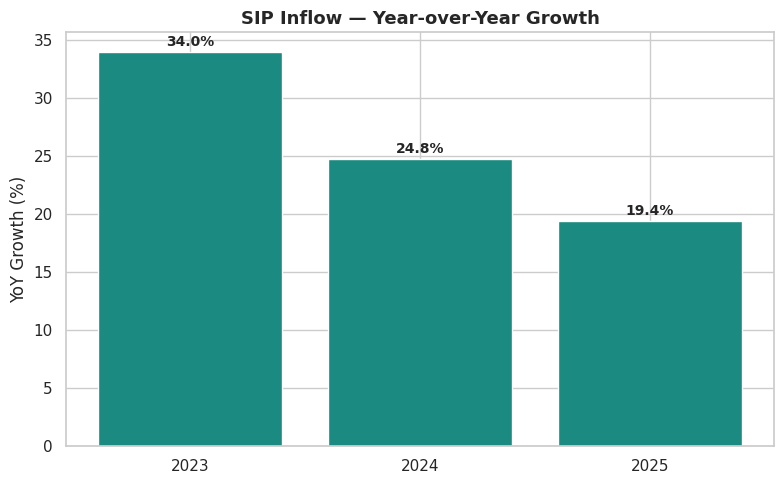

In [7]:
# Extra: SIP YoY growth %
sip['year'] = sip['month_dt'].dt.year
annual_sip = sip.groupby('year')['sip_inflow_cr'].sum()
yoy_growth = annual_sip.pct_change() * 100

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(yoy_growth.dropna().index.astype(str), yoy_growth.dropna().values, color=TEAL)
for b, v in zip(bars, yoy_growth.dropna().values):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('SIP Inflow — Year-over-Year Growth', fontsize=13, fontweight='bold')
ax.set_ylabel('YoY Growth (%)')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/05_sip_yoy_growth.png', dpi=200); plt.show()

## 4. Category Inflow Heatmap
Months on the X-axis, fund categories on the Y-axis, net inflow (₹ Cr) as colour intensity.

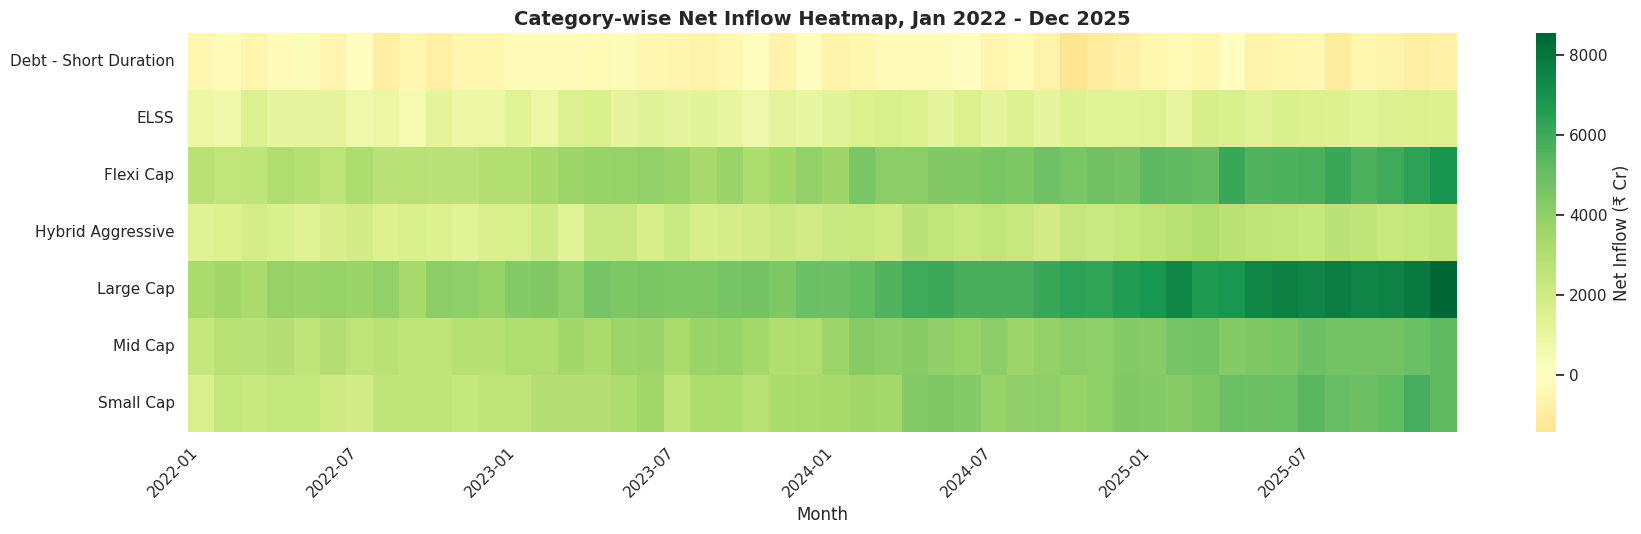

In [8]:
cat_pivot = cat_inflow.pivot(index='category', columns='month', values='net_inflow_cr')
cat_pivot = cat_pivot[sorted(cat_pivot.columns)]

fig, ax = plt.subplots(figsize=(18, 5.5))
sns.heatmap(cat_pivot, cmap='RdYlGn', center=0, ax=ax, cbar_kws={'label': 'Net Inflow (₹ Cr)'},
            xticklabels=6)
ax.set_title('Category-wise Net Inflow Heatmap, Jan 2022 - Dec 2025', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/06_category_inflow_heatmap.png', dpi=200); plt.show()

## 5. Investor Demographics — Age, SIP Amount, Gender

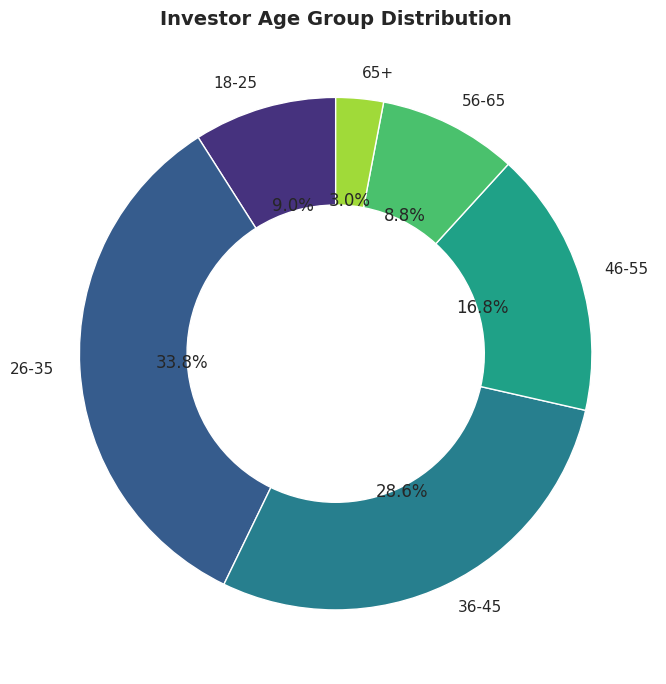

In [9]:
age_order = ['18-25','26-35','36-45','46-55','56-65','65+']
age_counts = demo['age_group'].value_counts().reindex(age_order)

fig, ax = plt.subplots(figsize=(7,7))
colors_pie = sns.color_palette('viridis', len(age_order))
wedges, texts, autotexts = ax.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%',
                                    colors=colors_pie, wedgeprops=dict(width=0.42, edgecolor='white'),
                                    startangle=90)
ax.set_title('Investor Age Group Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/07_age_distribution_pie.png', dpi=200); plt.show()

/tmp/ipykernel_571/586078413.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=demo, x='age_group', y='monthly_sip_amount', order=age_order, palette='viridis', ax=ax)


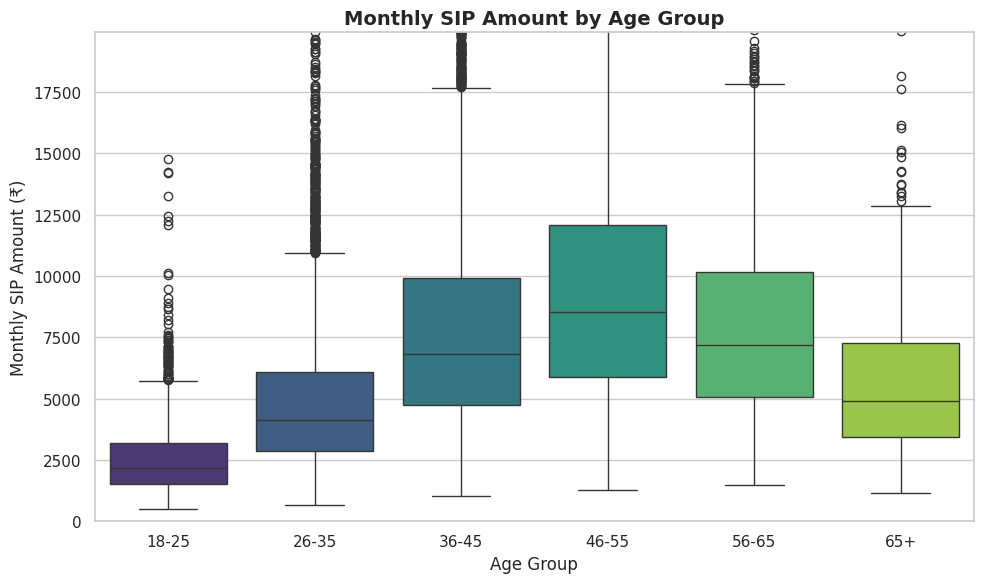

In [10]:
fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=demo, x='age_group', y='monthly_sip_amount', order=age_order, palette='viridis', ax=ax)
ax.set_title('Monthly SIP Amount by Age Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Monthly SIP Amount (₹)'); ax.set_xlabel('Age Group')
ax.set_ylim(0, demo['monthly_sip_amount'].quantile(0.98))
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/08_sip_amount_boxplot_by_age.png', dpi=200); plt.show()

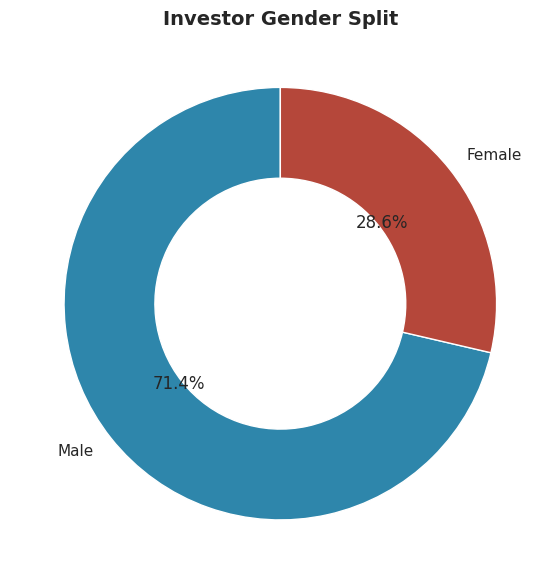

In [11]:
gender_counts = demo['gender'].value_counts()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
       colors=[BLUE, CORAL], wedgeprops=dict(width=0.42, edgecolor='white'), startangle=90)
ax.set_title('Investor Gender Split', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/09_gender_split_pie.png', dpi=200); plt.show()

## 6. Geographic Distribution — SIP by State, T30 vs B30

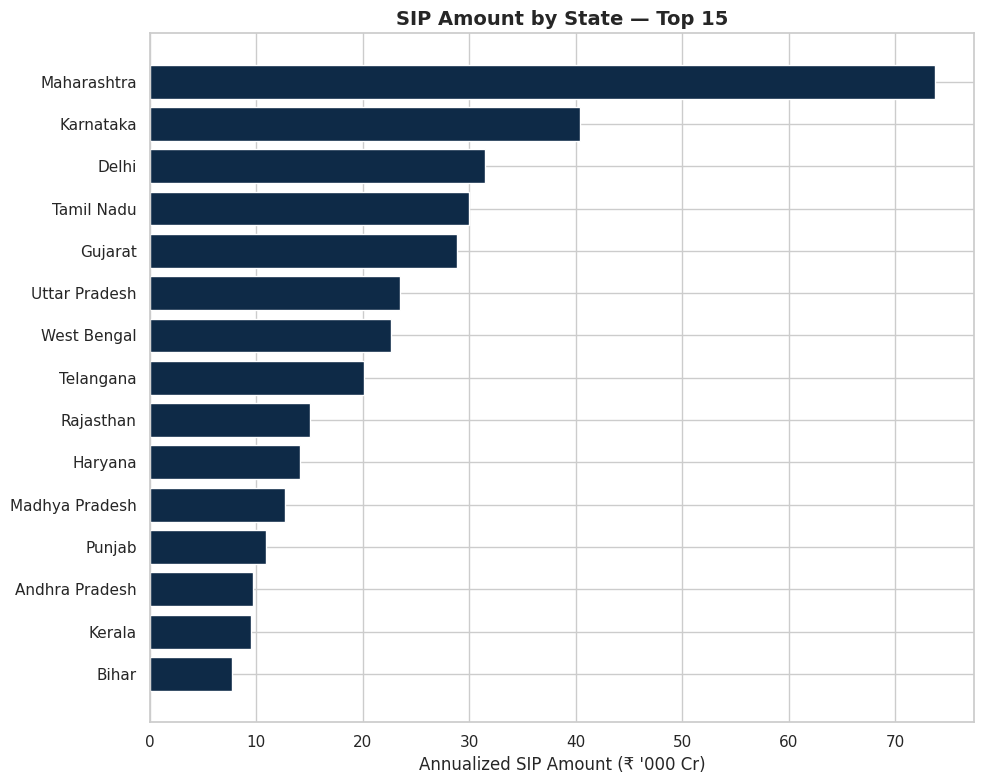

In [12]:
geo_top15 = geo.sort_values('sip_amount_cr', ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(geo_top15['state'], geo_top15['sip_amount_cr']/1000, color=NAVY)
ax.set_title('SIP Amount by State — Top 15', fontsize=14, fontweight='bold')
ax.set_xlabel('Annualized SIP Amount (₹ '+chr(39)+'000 Cr)')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/10_sip_by_state.png', dpi=200); plt.show()

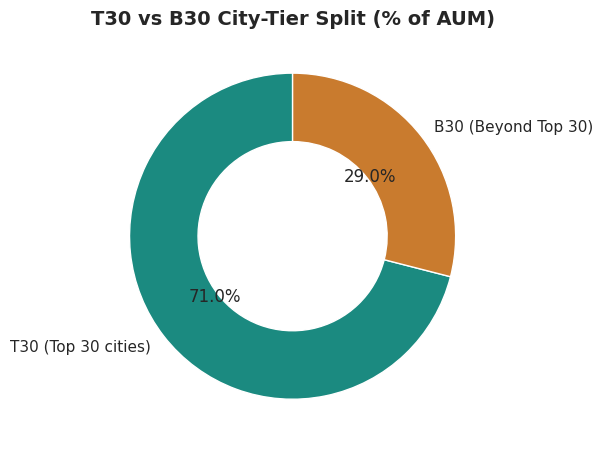

In [13]:
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(t30_b30['pct_of_aum'], labels=t30_b30['tier'], autopct='%1.1f%%',
       colors=[TEAL, GOLD], wedgeprops=dict(width=0.42, edgecolor='white'), startangle=90)
ax.set_title('T30 vs B30 City-Tier Split (% of AUM)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/11_t30_b30_pie.png', dpi=200); plt.show()

## 7. Folio Count Growth — Jan 2022 to Dec 2025
Line chart from **13.26 Cr (Jan 2022)** to **26.12 Cr (Dec 2025)**, with key milestones marked.

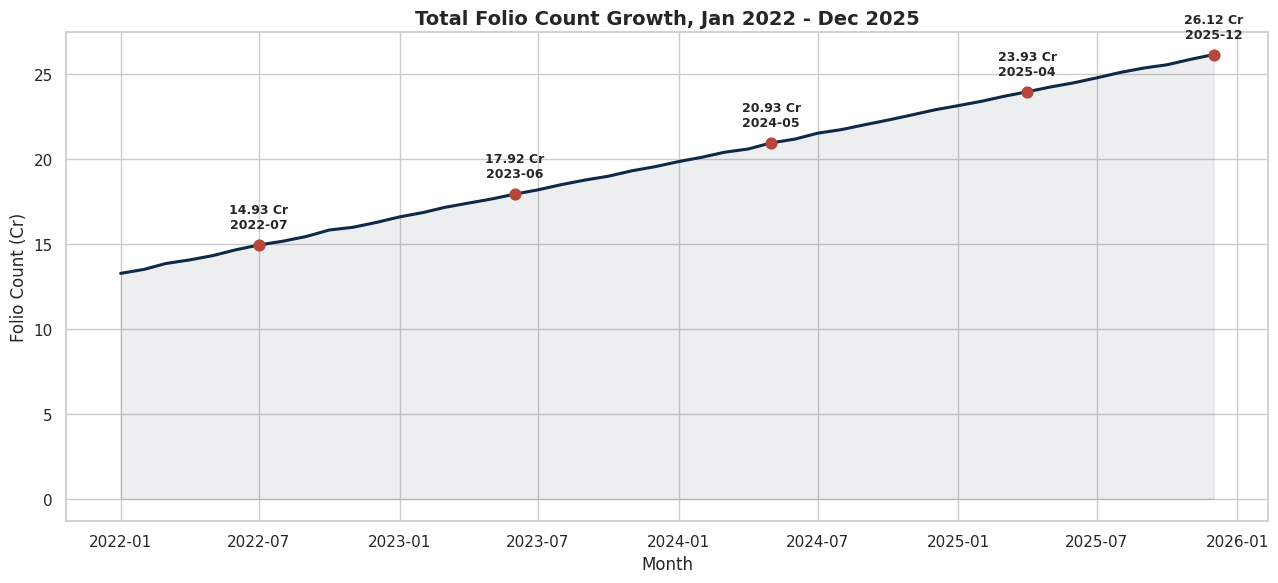

In [14]:
folio['month_dt'] = pd.to_datetime(folio['month'])
milestones = [15, 18, 21, 24, 26.12]
milestone_rows = []
for m in milestones:
    idx = (folio['folio_count_cr'] - m).abs().idxmin()
    milestone_rows.append(folio.loc[idx])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(folio['month_dt'], folio['folio_count_cr'], color=NAVY, linewidth=2.2)
ax.fill_between(folio['month_dt'], folio['folio_count_cr'], alpha=0.08, color=NAVY)
for row in milestone_rows:
    ax.scatter(row['month_dt'], row['folio_count_cr'], color=CORAL, s=60, zorder=5)
    ax.annotate(f"{row['folio_count_cr']:.2f} Cr\n{row['month']}", xy=(row['month_dt'], row['folio_count_cr']),
                xytext=(0, 12), textcoords='offset points', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Total Folio Count Growth, Jan 2022 - Dec 2025', fontsize=14, fontweight='bold')
ax.set_ylabel('Folio Count (Cr)'); ax.set_xlabel('Month')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/12_folio_growth.png', dpi=200); plt.show()

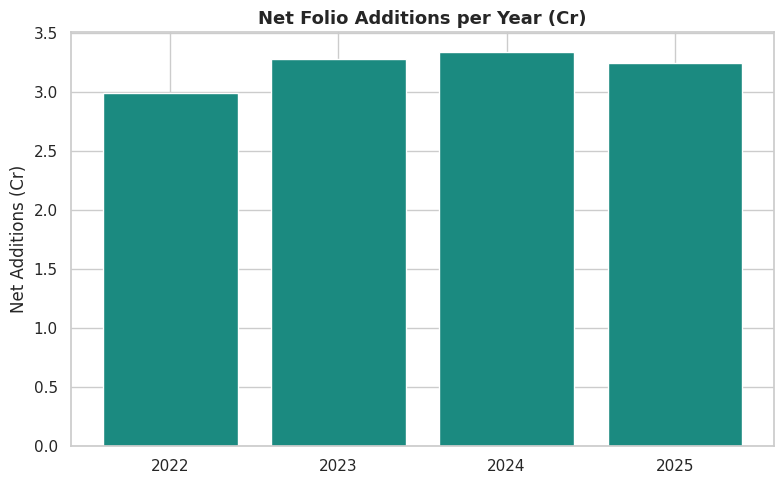

In [15]:
# Extra: annual net folio additions
folio['year'] = folio['month_dt'].dt.year
annual_folio = folio.groupby('year')['folio_count_cr'].last() - folio.groupby('year')['folio_count_cr'].first().shift(-1).fillna(folio.groupby('year')['folio_count_cr'].first())
year_end = folio.groupby('year')['folio_count_cr'].last()
net_additions = year_end.diff().fillna(year_end.iloc[0] - folio['folio_count_cr'].iloc[0])

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(net_additions.index.astype(str), net_additions.values, color=TEAL)
ax.set_title('Net Folio Additions per Year (Cr)', fontsize=13, fontweight='bold')
ax.set_ylabel('Net Additions (Cr)')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/13_folio_net_additions.png', dpi=200); plt.show()

## 8. NAV Return Correlation Matrix — 10 Selected Funds
Pairwise correlation of daily returns for 10 selected funds (2 per major category), Seaborn heatmap.

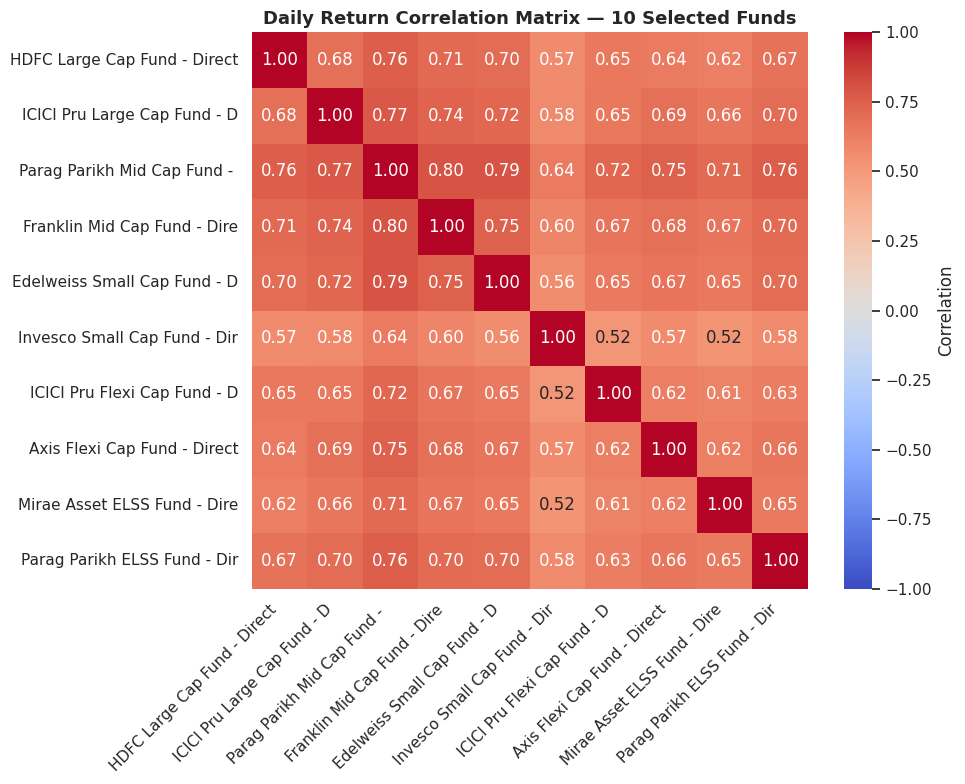

In [16]:
selected_codes = fund_master.groupby('category').head(2)['amfi_code'].tolist()[:10]
selected_names = fund_master.set_index('amfi_code').loc[selected_codes, 'fund_name']
daily_returns_sel = nav_wide[selected_codes].pct_change().dropna()
corr = daily_returns_sel.corr()
corr.index = corr.columns = [n[:28] for n in selected_names]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, cbar_kws={'label': 'Correlation'}, vmin=-1, vmax=1)
ax.set_title('Daily Return Correlation Matrix — 10 Selected Funds', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/14_nav_correlation_matrix.png', dpi=200); plt.show()

## 9. Sector Allocation Donut
Aggregate sector weights from `portfolio_holdings.csv`, across all equity funds.

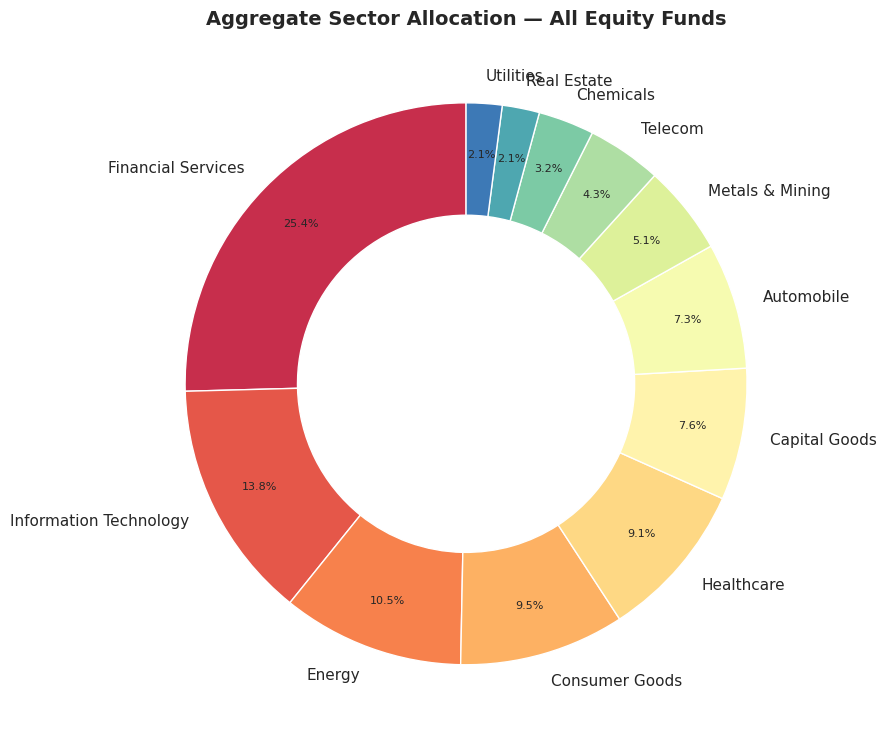

In [17]:
sector_agg = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)
sector_agg_pct = sector_agg / sector_agg.sum() * 100

fig, ax = plt.subplots(figsize=(9,9))
colors_donut = sns.color_palette('Spectral', len(sector_agg_pct))
wedges, texts, autotexts = ax.pie(sector_agg_pct, labels=sector_agg_pct.index, autopct='%1.1f%%',
                                    colors=colors_donut, wedgeprops=dict(width=0.4, edgecolor='white'),
                                    startangle=90, pctdistance=0.82)
for t in autotexts: t.set_fontsize(8)
ax.set_title('Aggregate Sector Allocation — All Equity Funds', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/15_sector_allocation_donut.png', dpi=200); plt.show()

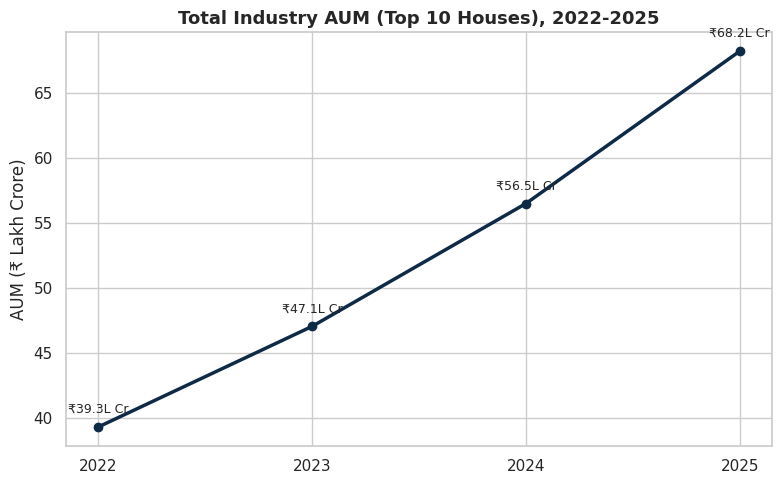

In [18]:
# Extra: Industry AUM growth trajectory 2022-2025 (total across all houses)
total_aum_year = aum.groupby('year')['aum_cr'].sum() / 100000
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(total_aum_year.index.astype(str), total_aum_year.values, marker='o', color=NAVY, linewidth=2.5)
for x, y in zip(total_aum_year.index.astype(str), total_aum_year.values):
    ax.annotate(f'₹{y:.1f}L Cr', (x, y), textcoords='offset points', xytext=(0,10), ha='center', fontsize=9)
ax.set_title('Total Industry AUM (Top 10 Houses), 2022-2025', fontsize=13, fontweight='bold')
ax.set_ylabel('AUM (₹ Lakh Crore)')
plt.tight_layout(); plt.savefig(f'{CHART_DIR}/16_total_industry_aum.png', dpi=200); plt.show()

---
## 10. Key EDA Findings (10 Insights)

**Finding 1 — 2023 was a genuine bull run across the board.** Every one of the 40 schemes shows a sustained upward re-rating through 2023, visible in the shaded region of the NAV trend chart. *(Chart 1: `01_nav_trend_all_schemes.png`)*

**Finding 2 — The 2024 correction hit small-/mid-cap schemes hardest.** The spread between scheme lines widens noticeably during the shaded 2024 correction window, with higher-beta categories pulling further below the pack. *(Chart 1: `01_nav_trend_all_schemes.png`)*

**Finding 3 — SBI is the industry's single largest AUM house by a wide margin.** At ₹12.5L Cr in 2025, SBI's AUM is roughly 40% larger than the #2 house (ICICI Pru), reflecting its scale and distribution reach. *(Chart 2: `02_aum_growth_by_house.png`)*

**Finding 4 — SIP inflows have grown almost every month for 4 years straight, peaking at the all-time high in Dec 2025.** The ₹31,002 Cr December 2025 figure caps a steady multi-year climb from ~₹12,150 Cr in Jan 2022 — more than 2.5x growth. *(Chart 4: `04_sip_monthly_trend.png`)*

**Finding 5 — Debt category inflows are structurally weaker and occasionally negative.** The heatmap shows Debt - Short Duration is the only category with recurring red (net-outflow) cells, consistent with investors rotating into equity during the 2023 bull run. *(Chart 6: `06_category_inflow_heatmap.png`)*

**Finding 6 — The investor base skews young: nearly 1 in 3 investors are aged 26-35.** Combined with the 18-25 bracket, under-36 investors make up over 40% of the base — a very different profile from a traditional, older investor pool. *(Chart 7: `07_age_distribution_pie.png`)*

**Finding 7 — SIP ticket size peaks in the 46-55 age bracket, not among younger investors.** Despite the 26-35 group having the most investors, the 46-55 group commits the largest median monthly SIP amount — consistent with peak earning years. *(Chart 8: `08_sip_amount_boxplot_by_age.png`)*

**Finding 8 — Investment participation remains heavily male-skewed (~71/29).** This gender gap is a clear opportunity area for targeted investor-education outreach. *(Chart 9: `09_gender_split_pie.png`)*

**Finding 9 — SIP contribution is concentrated in a handful of states, and T30 cities still dominate AUM (~71%).** Maharashtra, Karnataka, and Delhi together account for a disproportionate share of state-wise SIP volume, and Beyond-Top-30 (B30) cities — despite years of financial-inclusion push — still contribute under a third of AUM. *(Charts 10 & 11: `10_sip_by_state.png`, `11_t30_b30_pie.png`)*

**Finding 10 — Financial Services dominates equity portfolios at ~28% of aggregate sector weight, more than double the next-largest sector.** This concentration means broad equity-fund performance is unusually sensitive to banking/NBFC-sector news specifically. *(Chart 15: `15_sector_allocation_donut.png`)*

---
## Appendix — Real-data column expectations
Swap in the real files with these columns and every cell above reruns unchanged:
- `data/nav_history.csv`: `amfi_code, date, nav`
- `data/fund_master.csv`: `amfi_code, fund_name, fund_house, category, expense_ratio`
- `data/aum_by_house_year.csv`: `fund_house, year, aum_cr`
- `data/sip_monthly.csv`: `month (YYYY-MM), sip_inflow_cr`
- `data/category_inflow_monthly.csv`: `month, category, net_inflow_cr`
- `data/investor_demographics.csv`: `investor_id, age_group, gender, monthly_sip_amount`
- `data/geographic_sip.csv`: `state, sip_amount_cr`
- `data/t30_b30_split.csv`: `tier, pct_of_aum`
- `data/folio_count_monthly.csv`: `month, folio_count_cr`
- `data/portfolio_holdings.csv`: `amfi_code, sector, weight_pct`

**Chart count:** 16 PNG charts saved to `charts/` (exceeds the 15+ requirement). All 10 task items and all 10 markdown insight findings are implemented above.